In [208]:
import numpy as np
import pandas as pd
from mizani.breaks import date_breaks
from mizani.formatters import date_format
from plotnine import *
# Currently in a plotine dependancy they have deprication warning, so 
# we mute warnings to have a better experience
import warnings
warnings.filterwarnings("ignore")

# A nice color palette for categorical data 
cbPalette = ["#E69F00", "#56B4E9", "#009E73", 
             "#F0E442", "#0072B2", "#D55E00", 
             "#CC79A7", "#999999"]



In [209]:
data = pd.read_csv('AvfallsstatistikBRF2.csv', sep=',')
data[data['Fraktion'] == 'Restavfall'].head(10)
# print(np.unique(data['Fraktion']))

,Kundnr,Flexplatsadress,Flexgrupp,Fraktion,Flextyp,Flexplats,Utförande utfört,Enhet körtur,Vikt körtur
124,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-02,Kg,44.0
125,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-02,Kg,37.5
126,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-02,Kg,39.0
127,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-02,Kg,0.0
128,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-09,Kg,33.0
129,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-09,Kg,29.5
130,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-09,Kg,12.0
131,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-09,Kg,40.0
132,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-16,Kg,34.0
133,560013612,Eklandagatan 41,Kärl,Restavfall,370 liter,115839,2024-09-16,Kg,38.5


In [210]:
data['Utförande utfört'] = pd.to_datetime(data['Utförande utfört'])
data['Vikt'] = data['Vikt körtur']
data['Datum'] = data['Utförande utfört']
data = data.drop(columns=['Vikt körtur', 'Utförande utfört'])
day = (
    data.groupby([data['Datum'].dt.to_period('D'), 'Fraktion'])['Vikt']
      .sum()
      .reset_index()
)
day


,Datum,Fraktion,Vikt
0,2024-09-02,Matavfall,25.5
1,2024-09-02,Restavfall,120.5
2,2024-09-09,Matavfall,7.5
3,2024-09-09,Restavfall,114.5
4,2024-09-16,Matavfall,2.5
...,...,...,...
122,2025-10-13,Matavfall,12.5
123,2025-10-14,Restavfall,114.0
124,2025-10-20,Matavfall,58.0
125,2025-10-21,Restavfall,94.5


In [211]:
month = (
    data.groupby([data['Datum'].dt.to_period('M'), 'Fraktion'])['Vikt']
      .sum()
      .reset_index()
)
month

,Datum,Fraktion,Vikt
0,2024-09,Matavfall,41.5
1,2024-09,Restavfall,505.5
2,2024-10,Matavfall,45.5
3,2024-10,Restavfall,353.5
4,2024-11,Matavfall,49.0
5,2024-11,Restavfall,356.0
6,2024-12,Matavfall,56.0
7,2024-12,Restavfall,433.0
8,2025-01,Matavfall,45.0
9,2025-01,Restavfall,332.5


In [212]:
allDay = (
    data.groupby([data['Datum'].dt.to_period('D')])['Vikt']
      .sum()
      .reset_index()
)


In [213]:
allMonth = (
    data.groupby([data['Datum'].dt.to_period('M')])['Vikt']
      .sum()
      .reset_index()
)
allMonth

,Datum,Vikt
0,2024-09,547.0
1,2024-10,399.0
2,2024-11,405.0
3,2024-12,489.0
4,2025-01,377.5
5,2025-02,373.0
6,2025-03,465.0
7,2025-04,490.5
8,2025-05,491.0
9,2025-06,523.5


In [214]:
nollDagar = allDay[allDay['Vikt'] == 0]['Datum']
nollDagar

8     2024-10-27
33    2025-04-01
34    2025-04-02
40    2025-05-05
48    2025-06-02
84    2025-09-30
Name: Datum, dtype: period[D]

In [ ]:
# day["Datum"] = day["Datum"].dt.to_timestamp()

# day = day.sort_values(["Fraktion", "Datum"])

# day["weight_7day_ma"] = (
#     day
#     .groupby("Fraktion")
#     .apply(lambda x:
#         x.set_index("Datum")["Vikt"]
#          .rolling("7D")
#          .mean()
#     )
#     .reset_index(level=0, drop=True)
# )


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
day[day['Datum'].isin(nollDagar)]

KeyError: 'Datum'

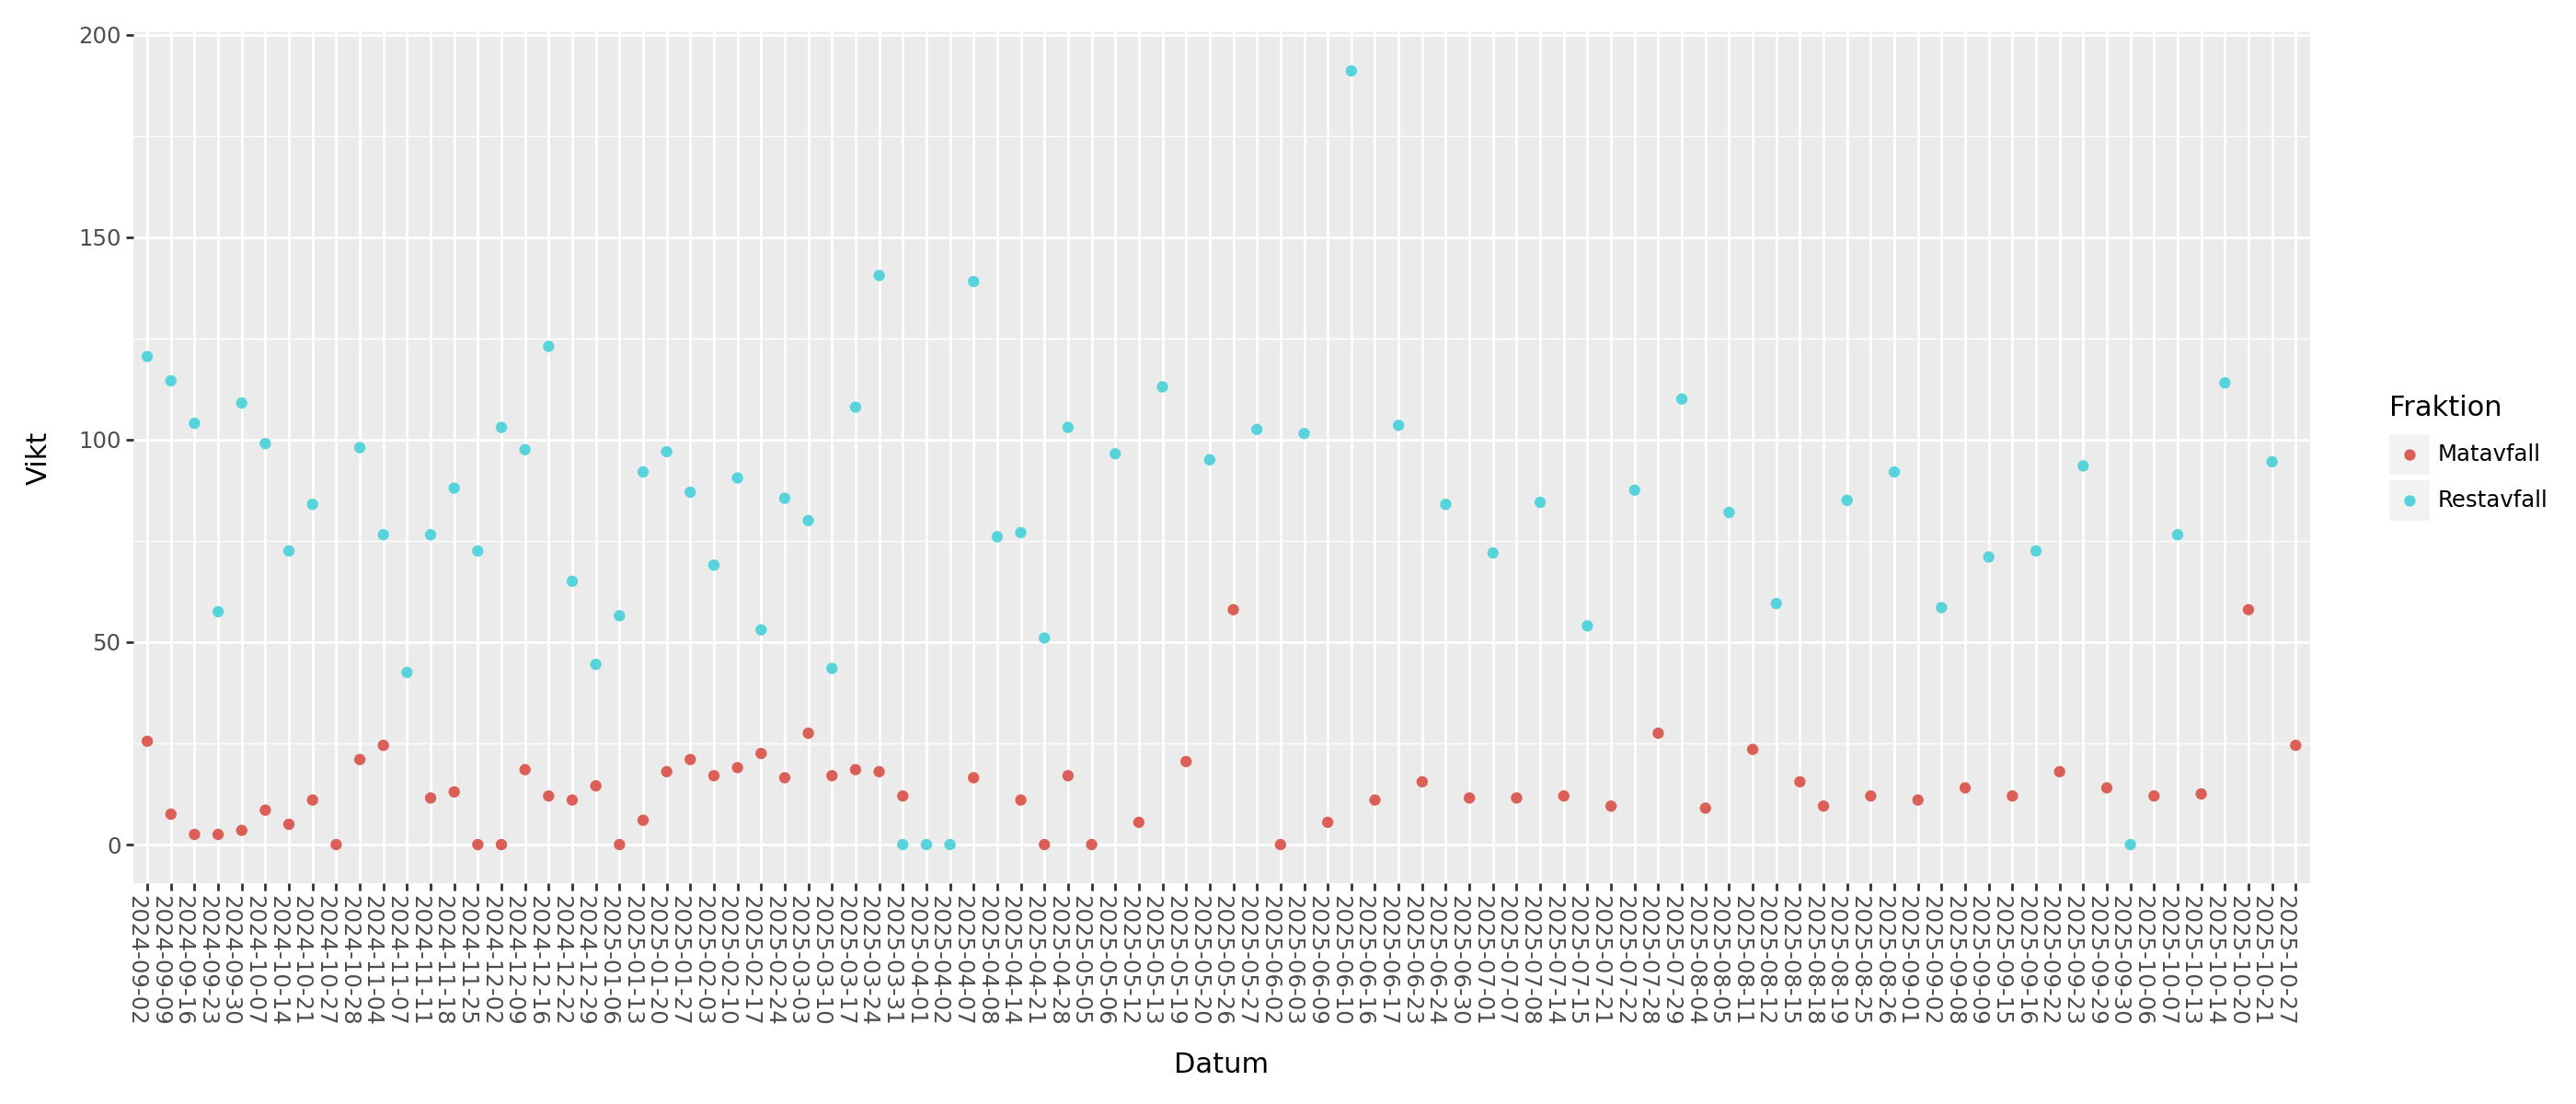

In [ ]:
dates = day['Datum']
p = (ggplot(day, aes("Datum", "Vikt", color="Fraktion"))
    + geom_point()
    + theme(axis_text_x=element_text(rotation=-90, ha='right'),
           figure_size=(14,6))
    )
p

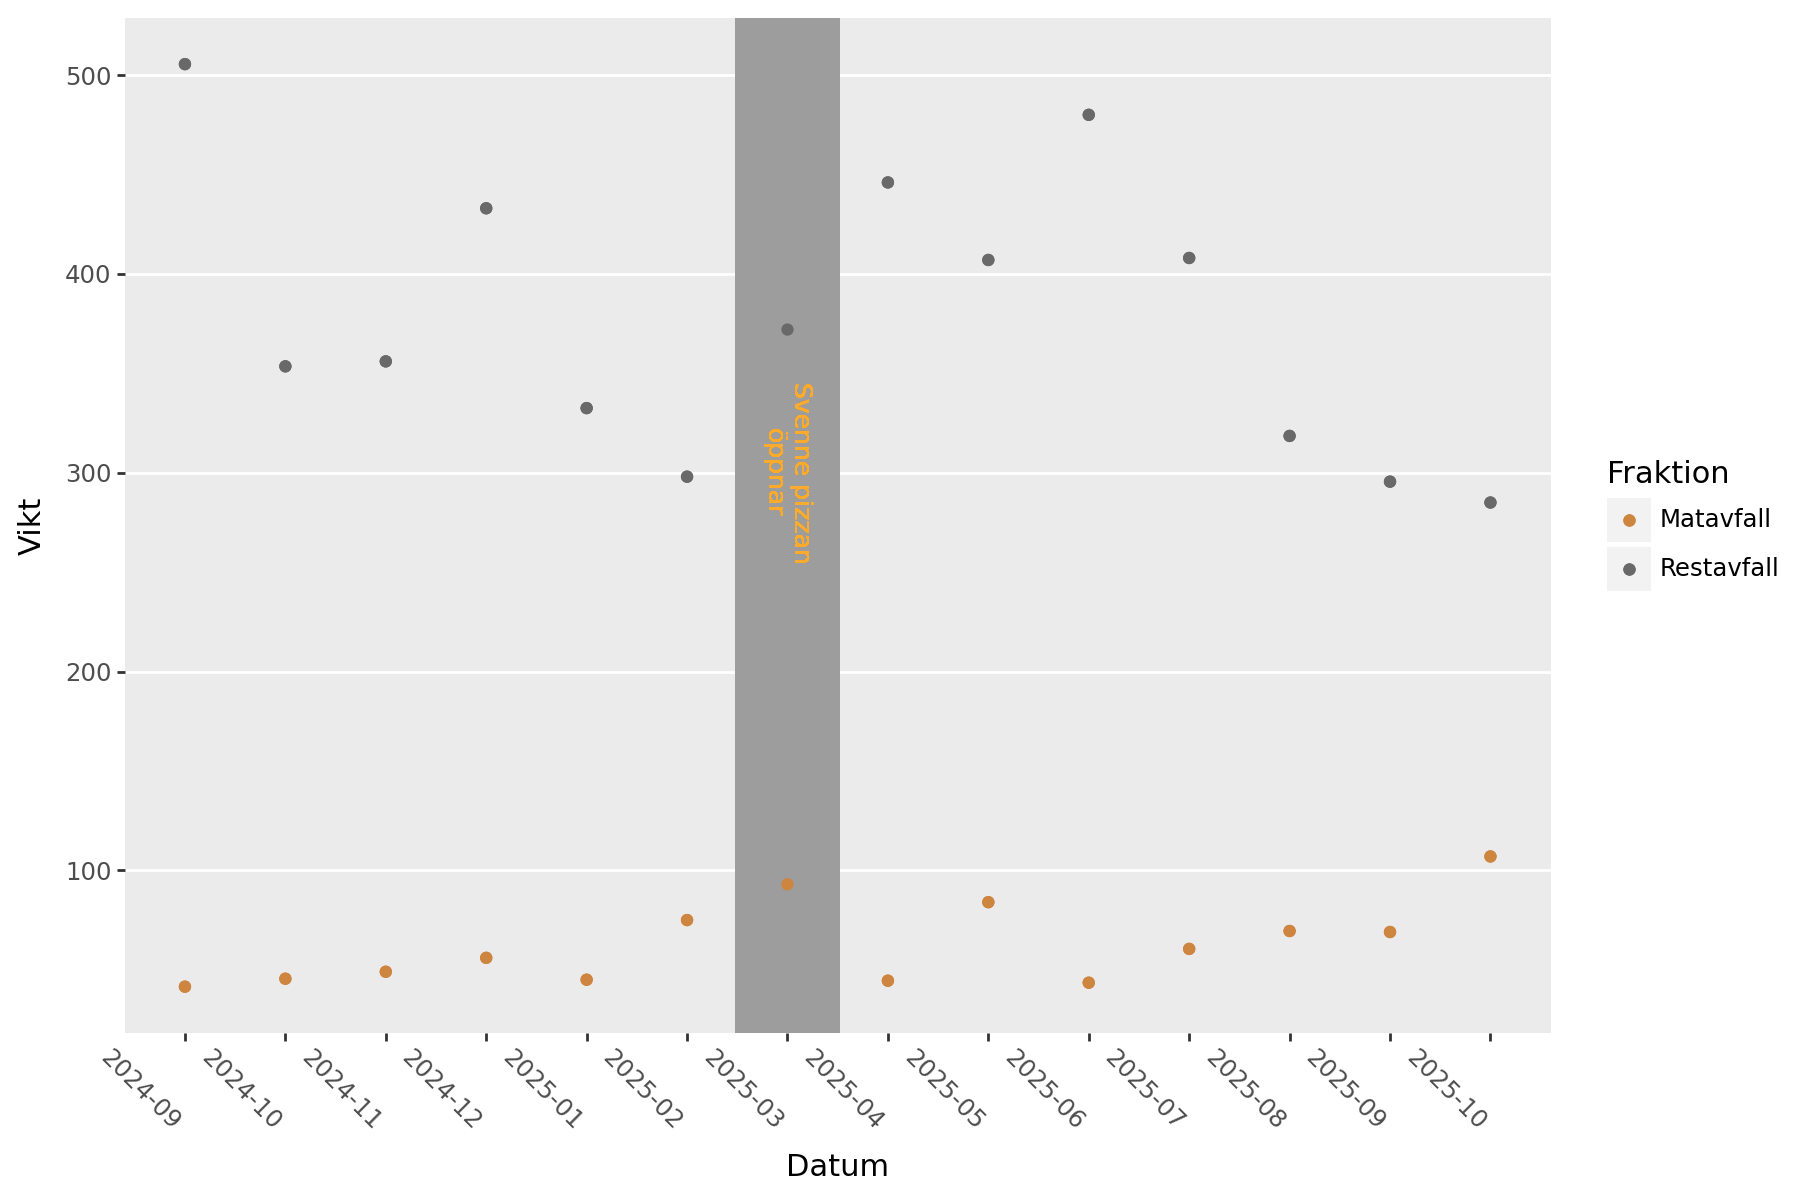

In [ ]:
p = (ggplot(month, aes("Datum", "Vikt", color="Fraktion"))
    
    + geom_point()
    + geom_rect(aes(xmin=6.5, xmax=7.5, ymin=-np.Inf, ymax=np.Inf), fill="#9d9d9d", alpha=1.0, color = "#9d9d9d")
    + geom_text(x=7, y=300, angle=-90, label='Svenne pizzan\nöppnar', size = 9, color = '#FFAC2C', ha = 'center')
    + geom_point()
    # + theme_minimal()
    + scale_color_manual(['peru', 'dimgray'])
    + theme(axis_text_x=element_text(rotation=-45, ha='right'),
             panel_grid_major_x=element_blank(),
             panel_grid_minor_x=element_blank(),
             panel_grid_minor_y=element_blank(),
             figure_size=(9,6)
             )
    )
p

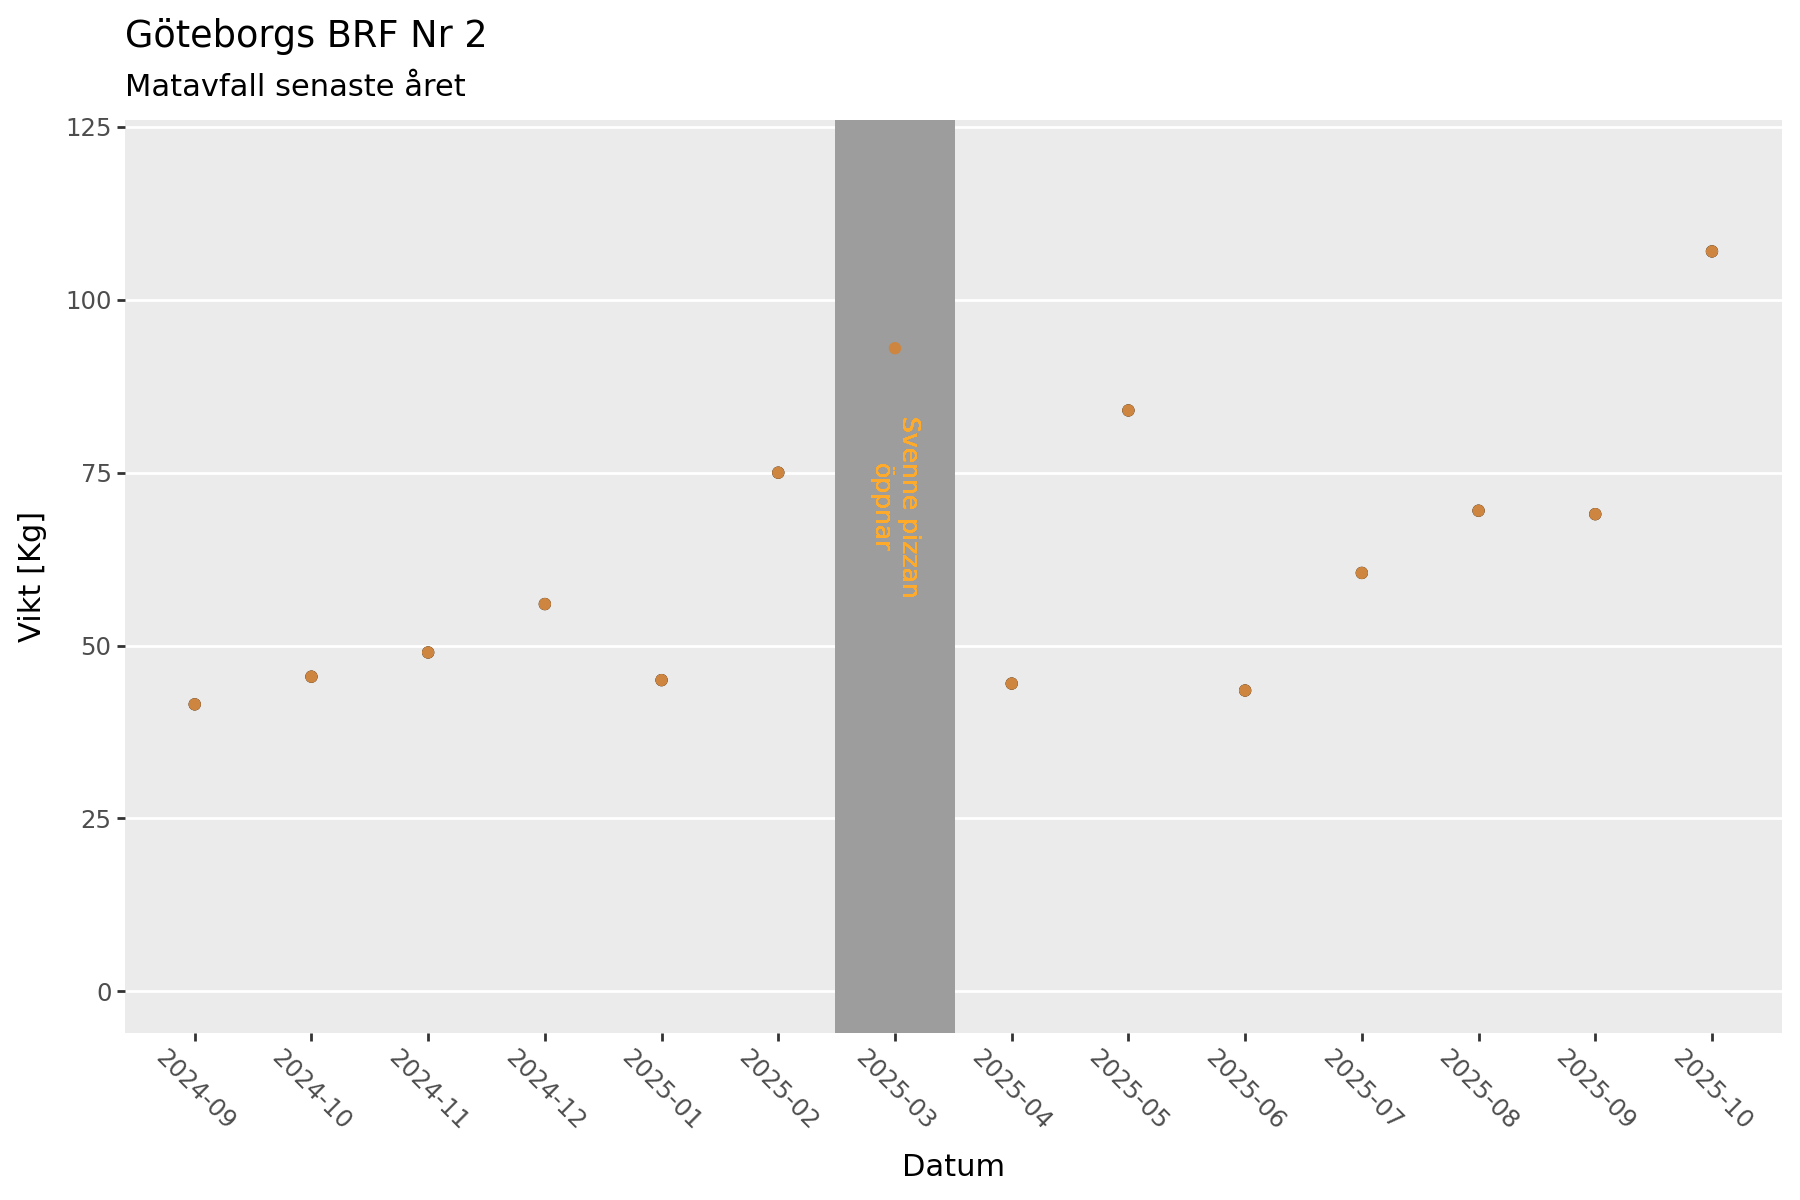

In [ ]:
p = (ggplot(month[month['Fraktion'] == 'Matavfall'], aes("Datum", "Vikt"))
    + geom_point()
    + geom_rect(aes(xmin=6.5, xmax=7.5, ymin=-np.Inf, ymax=np.Inf), fill="#9d9d9d", alpha=1.0, color = "#9d9d9d")
    + geom_point(color='peru')
    # + geom_vline(xintercept=11, alpha=.4, size=1, linetype='dotted')
    # + theme_minimal()
    + geom_text(x=7, y=70, angle=-90, label='Svenne pizzan\nöppnar', size = 9, color = '#FFAC2C', ha = 'center')
    # + geom_text(x=11.3, y=35, angle=-90, label='Operation Kjëll inleds', size = 9, color = '#444444', ha = 'center')
    + labs(x = "Datum", y = "Vikt [Kg]", title = 'Göteborgs BRF Nr 2', subtitle='Matavfall senaste året')
    + ylim((0, 120))
    + theme(axis_text_x=element_text(rotation=-45),
             panel_grid_major_x=element_blank(),
             panel_grid_minor_x=element_blank(),
             panel_grid_minor_y=element_blank(),
             figure_size=(9,6)
             )
    )
p

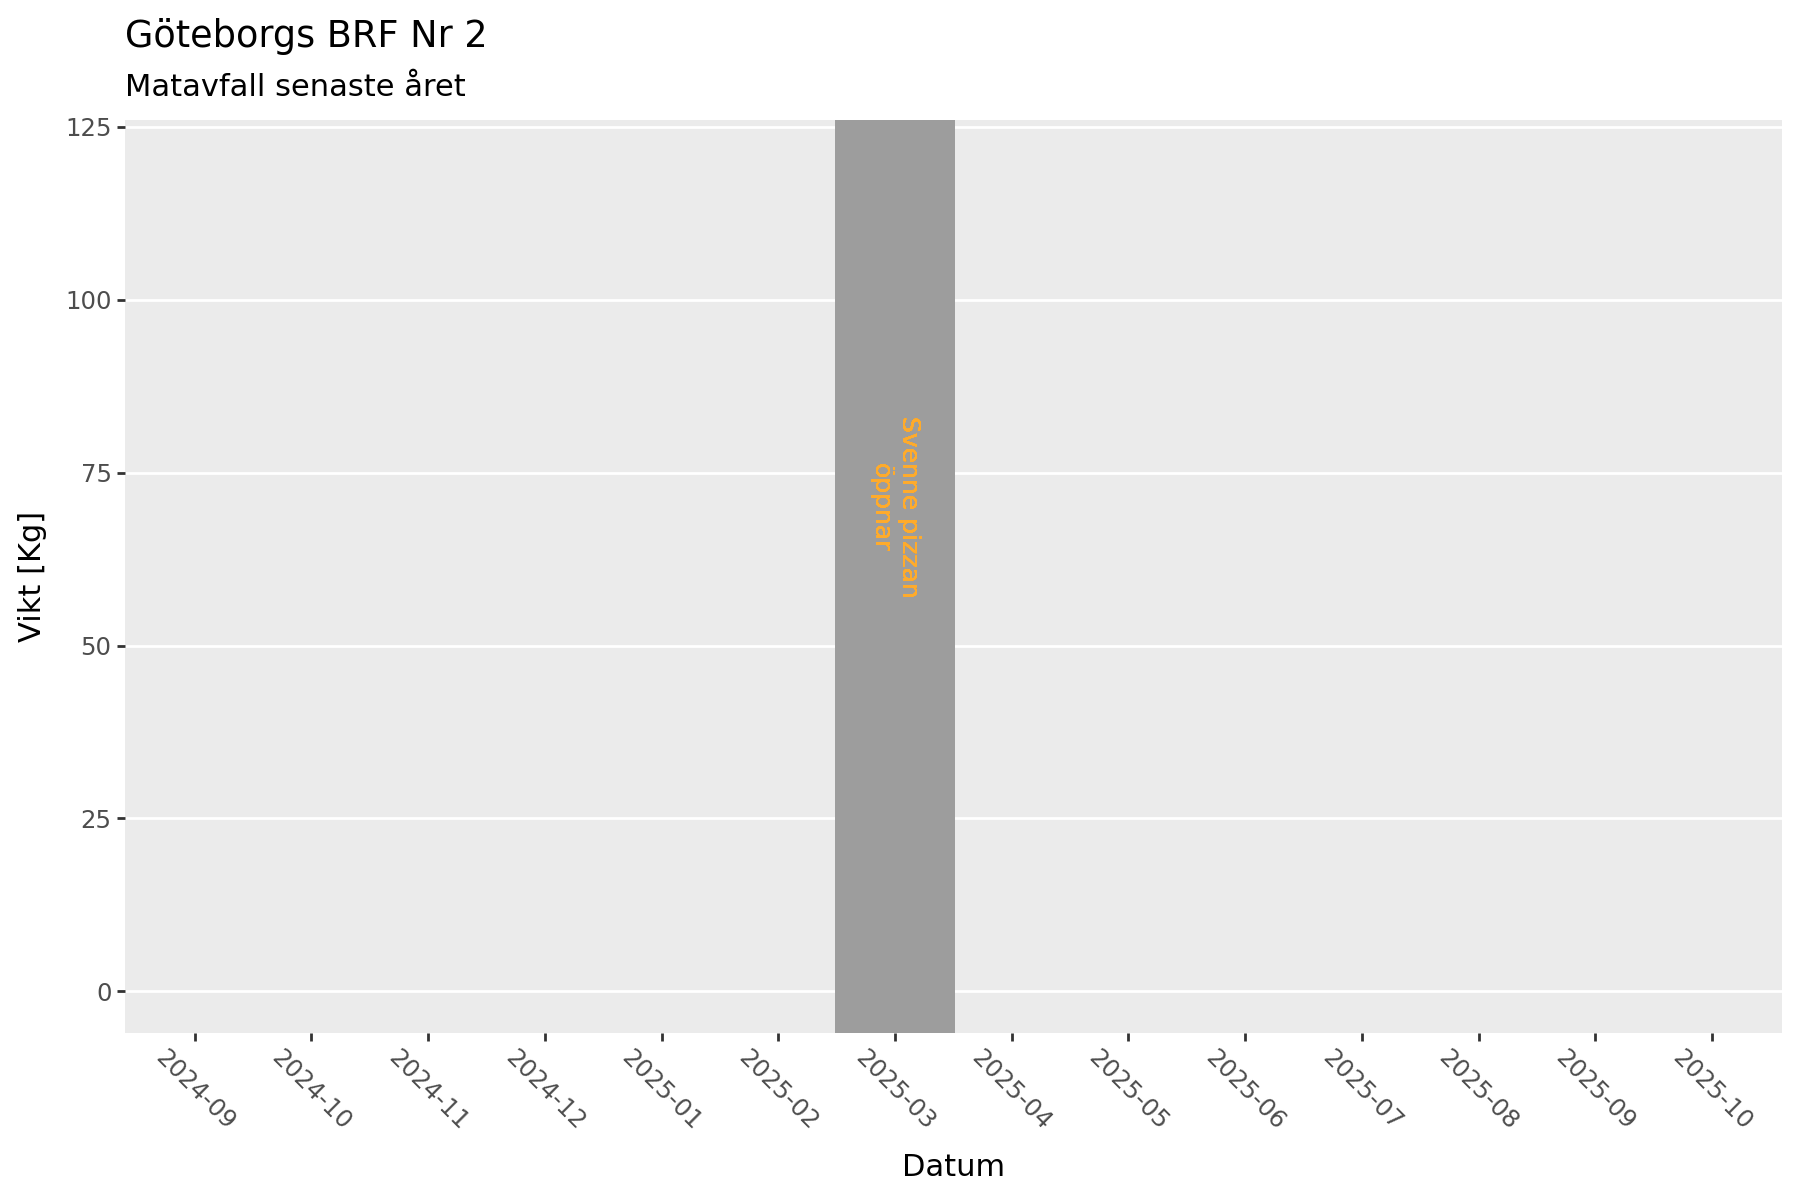

In [ ]:
p = (ggplot(month[month['Fraktion'] == 'Restavfall'], aes("Datum", "Vikt"))
    + geom_point()
    + geom_rect(aes(xmin=6.5, xmax=7.5, ymin=-np.Inf, ymax=np.Inf), fill="#9d9d9d", alpha=1.0, color = "#9d9d9d")
    + geom_point(color='peru')
    # + geom_vline(xintercept=11, alpha=.4, size=1, linetype='dotted')
    # + theme_minimal()
    + geom_text(x=7, y=70, angle=-90, label='Svenne pizzan\nöppnar', size = 9, color = '#FFAC2C', ha = 'center')
    # + geom_text(x=11.3, y=35, angle=-90, label='Operation Kjëll inleds', size = 9, color = '#444444', ha = 'center')
    + labs(x = "Datum", y = "Vikt [Kg]", title = 'Göteborgs BRF Nr 2', subtitle='Matavfall senaste året')
    + ylim((0, 120))
    + theme(axis_text_x=element_text(rotation=-45),
             panel_grid_major_x=element_blank(),
             panel_grid_minor_x=element_blank(),
             panel_grid_minor_y=element_blank(),
             figure_size=(9,6)
             )
    )
p

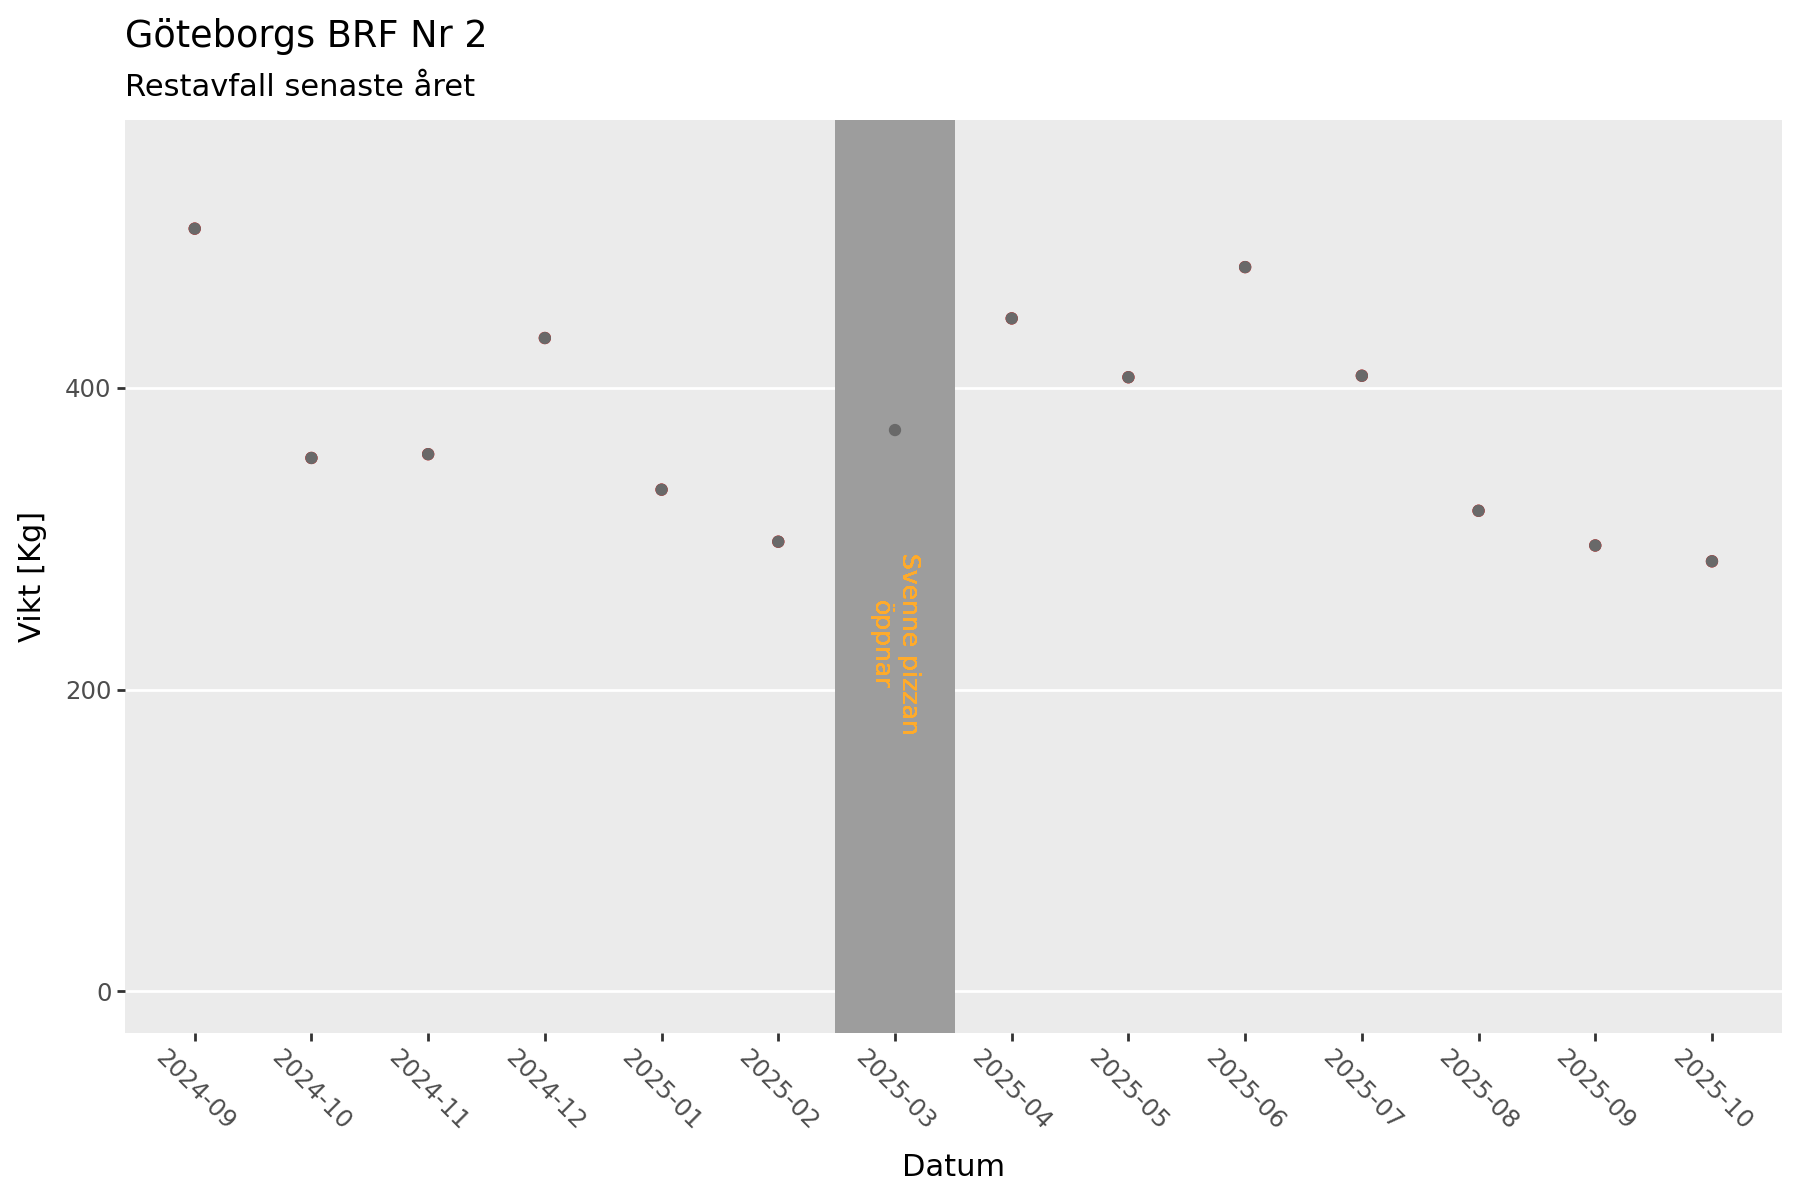

In [ ]:
p = (ggplot(month[month['Fraktion'] == 'Restavfall'], aes("Datum", "Vikt"))
    + geom_point(color='red')
    + geom_rect(aes(xmin=6.5, xmax=7.5, ymin=-np.Inf, ymax=np.Inf), fill="#9d9d9d", alpha=1.0, color = "#9d9d9d")
    # + geom_vline(xintercept=11, alpha=.4, size=1, linetype='dotted')
    + geom_point(color='dimgray')
    + ylim((0,550))
    # + theme_minimal()
    + geom_text(x=7, y=230, angle=-90, label='Svenne pizzan\nöppnar', size = 9, color = '#FFAC2C', ha = 'center')
    # + geom_text(x=11.3, y=230, angle=-90, label='Operation Kjëll inleds', size = 9, color = '#444444', ha = 'center')
    + labs(x = "Datum", y = "Vikt [Kg]", title = 'Göteborgs BRF Nr 2', subtitle='Restavfall senaste året')
    + theme(axis_text_x=element_text(rotation=-45),
             panel_grid_major_x=element_blank(),
             panel_grid_minor_x=element_blank(),
             panel_grid_minor_y=element_blank(),
             figure_size=(9,6)
             )
    )
p

In [ ]:
month

,Datum,Fraktion,Vikt
0,2024-09,Matavfall,41.5
1,2024-09,Restavfall,505.5
2,2024-10,Matavfall,45.5
3,2024-10,Restavfall,353.5
4,2024-11,Matavfall,49.0
5,2024-11,Restavfall,356.0
6,2024-12,Matavfall,56.0
7,2024-12,Restavfall,433.0
8,2025-01,Matavfall,45.0
9,2025-01,Restavfall,332.5


In [ ]:
allMonth

,Datum,Vikt
0,2024-09,547.0
1,2024-10,399.0
2,2024-11,405.0
3,2024-12,489.0
4,2025-01,377.5
5,2025-02,373.0
6,2025-03,465.0
7,2025-04,490.5
8,2025-05,491.0
9,2025-06,523.5


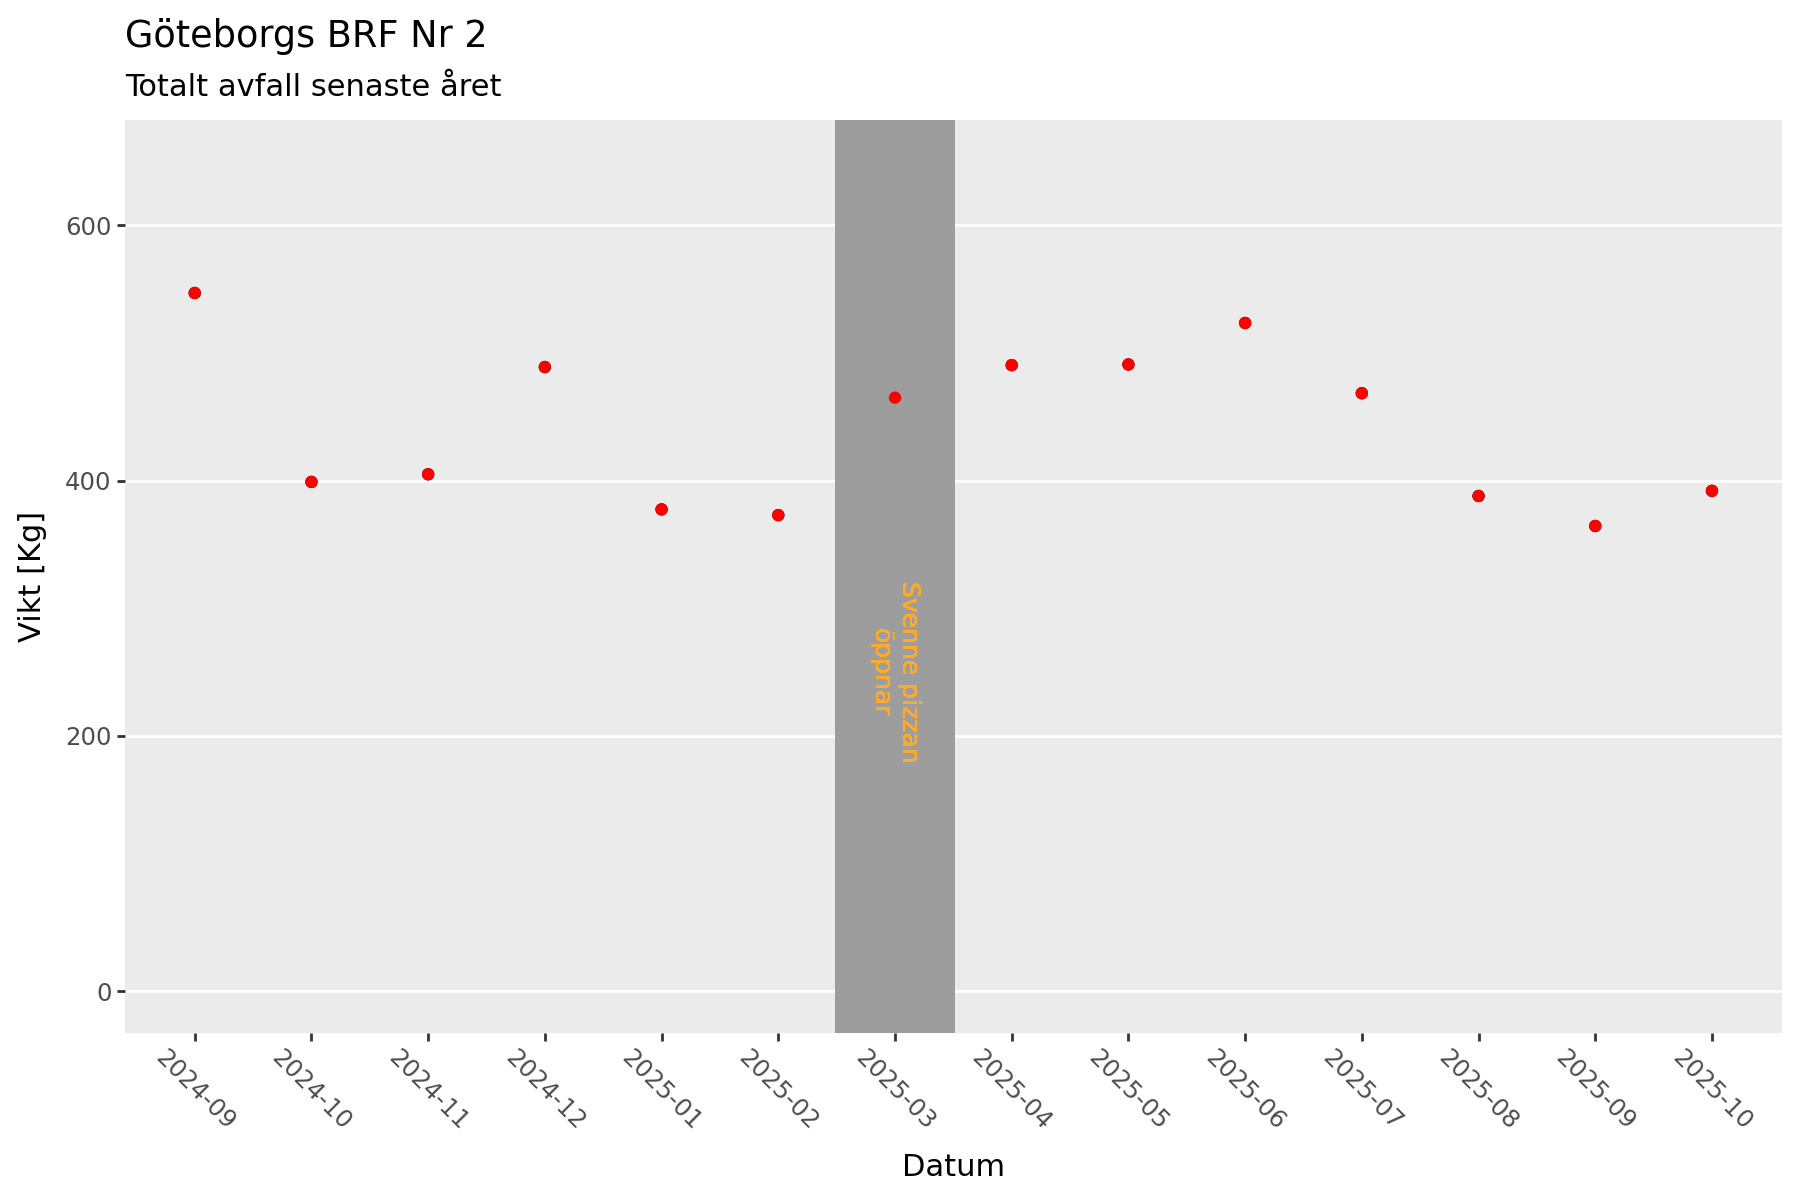

In [ ]:
p = (ggplot(allMonth, aes("Datum", "Vikt"))
    + geom_point()
    + geom_rect(aes(xmin=6.5, xmax=7.5, ymin=-np.Inf, ymax=np.Inf), fill="#9d9d9d", alpha=1.0, color = "#9d9d9d")
    + geom_point(color='red')
    # + geom_vline(xintercept=11, alpha=.4, size=1, linetype='dotted')
    # + theme_minimal()
    + geom_text(x=7, y=250, angle=-90, label='Svenne pizzan\nöppnar', size = 9, color = '#FFAC2C', ha = 'center')
    # + geom_text(x=11.3, y=250, angle=-90, label='Operation Kjëll inleds', size = 9, color = '#444444', ha = 'center')
    + labs(x = "Datum", y = "Vikt [Kg]", title = 'Göteborgs BRF Nr 2', subtitle='Totalt avfall senaste året')
    + ylim((0, 650))
    + theme(axis_text_x=element_text(rotation=-45),
             panel_grid_major_x=element_blank(),
             panel_grid_minor_x=element_blank(),
             panel_grid_minor_y=element_blank(),
             figure_size=(9,6)
             )
    )
p